<a href="https://colab.research.google.com/github/MalavMDesai/GenAIAssignment/blob/main/Assignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [59]:
url="https://github.com/MalavMDesai/GenAIAssignment/raw/refs/heads/main/assignment4.csv"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()
df

,Area,Bedrooms,Price
0,2097,3,382000.0
1,2211,4,472000.0
2,1662,3,344000.0
3,1897,5,444000.0
4,2095,2,367000.0
5,2902,3,565000.0
6,1660,3,277000.0
7,3042,5,548000.0
8,1723,5,340000.0
9,2438,5,496000.0


In [60]:
features = df[['Area', 'Bedrooms']]
target = df['Price']
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=827
)

In [61]:
model = LinearRegression()
model.fit(scaler.transform(features_train), target_train)
target_pred = model.predict(scaler.transform(features_test))
print("MAE:", mean_absolute_error(target_test, target_pred))
print("MSE:", mean_squared_error(target_test, target_pred))
print("R2 Score:", r2_score(target_test, target_pred))
target_pred

MAE: 21323.67463492902
MSE: 746374542.293267
R2 Score: 0.9398958011554777


array([409507.98677292, 546615.7882417 , 456212.4916734 , 248361.88191311,
       297580.33059009, 383018.23857133, 353813.48052181, 244985.28602052,
       345549.61974955, 515437.7856641 ])

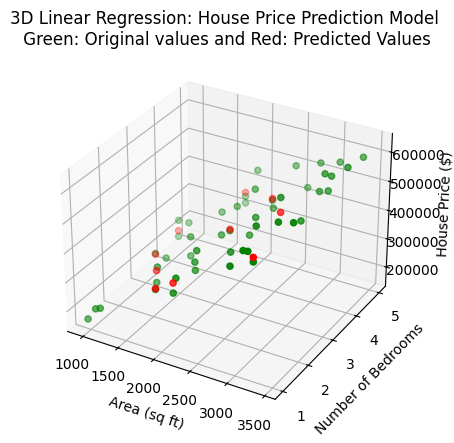

In [62]:
fig=plt.figure()
ax=fig.add_subplot(111,projection='3d')
scat=ax.scatter(features_train['Area'],
                features_train['Bedrooms'],
                target_train,
                color='green')
scat=ax.scatter(features_test['Area'],
                features_test['Bedrooms'],
                target_test,
                color='green')
scat=ax.scatter(features_test['Area'],
                features_test['Bedrooms'],
                target_pred,
                color='red')

ax.set_title('3D Linear Regression: House Price Prediction Model\n Green: Original values and Red: Predicted Values')
ax.set_xlabel('Area (sq ft)')
ax.set_ylabel('Number of Bedrooms')
ax.set_zlabel('House Price ($)')

plt.show()